### EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filters

<div align="right">
<strong>Index No: 230563H</strong>
</div>

#### Q1.

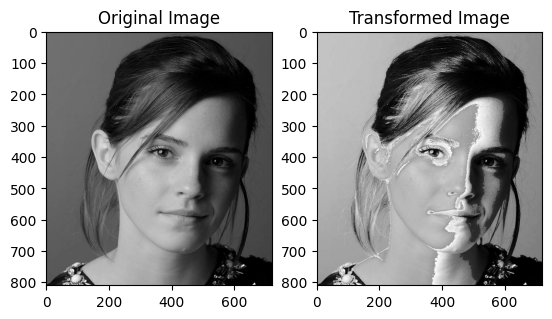

In [4]:
import cv2 
import matplotlib.pyplot as plt 
import numpy as np 

#intensity transformation fucntion
def intensity_transformation(im,breakpoints):
    x,y=zip(*breakpoints)
    t_im=np.interp(im,x,y)
    return t_im

breakpoints=[(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]

im=cv2.imread(r"C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig1b.png",cv2.IMREAD_GRAYSCALE)
t_im=intensity_transformation(im,breakpoints)
plt.subplot(1,2,1)
plt.imshow(im,cmap='gray',vmin=0,vmax=255)
plt.title("Original Image") 
plt.subplot(1,2,2)
plt.imshow(t_im,cmap='gray',vmin=0,vmax=255)
plt.title("Transformed Image") 
plt.show()


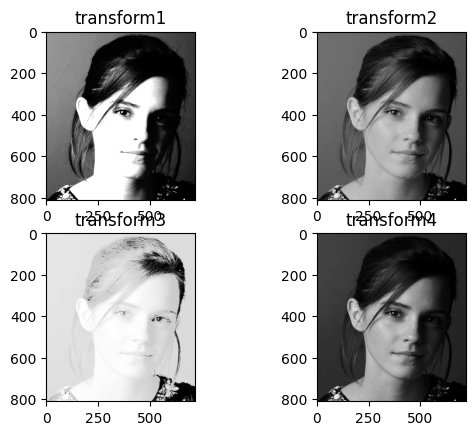

In [5]:
#experiment with different breakpoints to see the effect of intensity transformation on the image.
breakpoints1=[(0,0),(60,10),(150,255),(255,255)]
breakpoints2=[(0,0),(255,255)]
breakpoints3=[(0,0),(10,200),(200,255),(255,255)]
breakpoints4=[(0,0),(100,50),(200,200),(255,255)]

t_im1=intensity_transformation(im,breakpoints1)
t_im2=intensity_transformation(im,breakpoints2)
t_im3=intensity_transformation(im,breakpoints3)
t_im4=intensity_transformation(im,breakpoints4)

plt.subplot(2,2,1)
plt.imshow(t_im1,cmap='gray',vmin=0,vmax=255)
plt.title("transform1") 
plt.subplot(2,2,2)
plt.imshow(t_im2,cmap='gray',vmin=0,vmax=255)
plt.title("transform2")
plt.subplot(2,2,3)  
plt.imshow(t_im3,cmap='gray',vmin=0,vmax=255)
plt.title("transform3")
plt.subplot(2,2,4)
plt.imshow(t_im4,cmap='gray',vmin=0,vmax=255)
plt.title("transform4")


plt.show()



### Q2.

Thresholds: 45, 124, 186


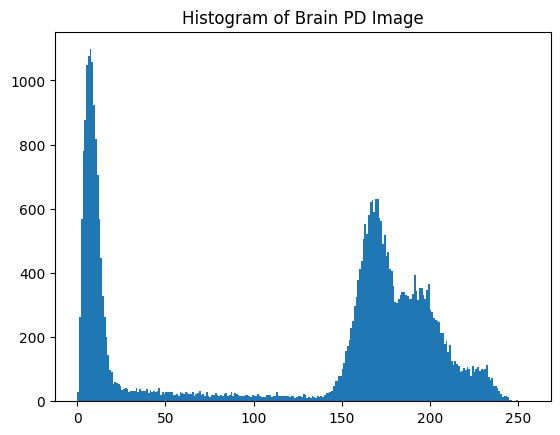

In [6]:
from skimage.filters import threshold_multiotsu

brain_img = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig2.png', cv2.IMREAD_GRAYSCALE)

thresholds = threshold_multiotsu(brain_img, classes=4)
t1, t2, t3 = thresholds

print(f"Thresholds: {t1}, {t2}, {t3}")
plt.hist(brain_img.ravel(), bins=256, range=[0,256])
plt.title('Histogram of Brain PD Image')
plt.show()

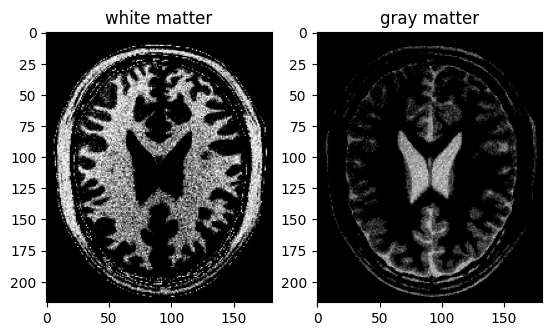

In [9]:
breakpointwhite=[(0, 0), (124, 0), (155, 255), (186, 0), (255, 0)]
breakpointgray=[(0, 0), (186, 0), (255, 255)]

t_im_white=intensity_transformation(brain_img,breakpointwhite)
t_im_gray=intensity_transformation(brain_img,breakpointgray)

plt.subplot(1,2,1)
plt.imshow(t_im_white,cmap='gray',vmin=0,vmax=255)
plt.title("white matter") 
plt.subplot(1,2,2)
plt.imshow(t_im_gray,cmap='gray',vmin=0,vmax=255)
plt.title("gray matter")
plt.show()

### Q3.

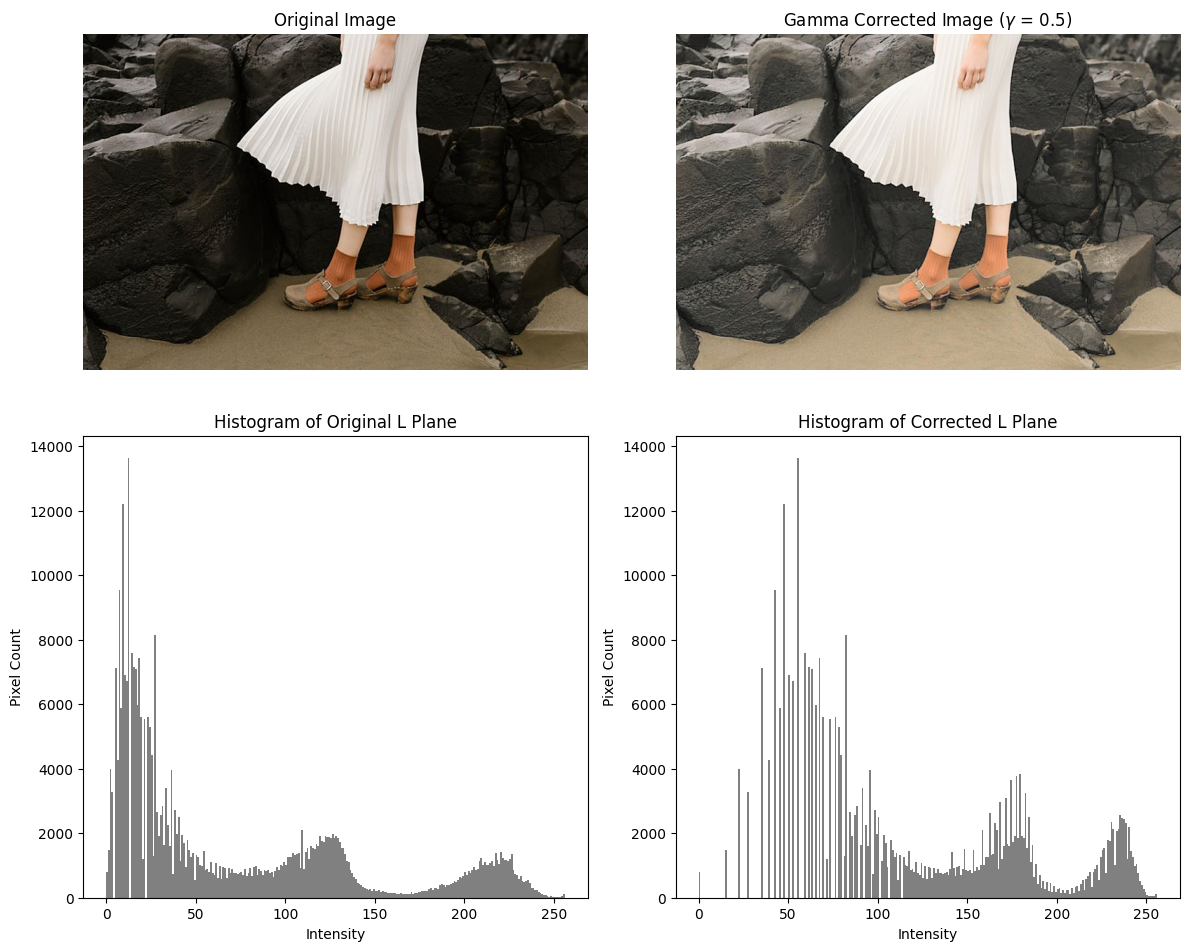

In [20]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig3.png')
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(img_lab)
gamma = 0.5


L_normalized = L / 255.0
L_corrected = (L_normalized ** gamma) * 255.0
L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)
img_lab_corrected = cv2.merge((L_corrected, a, b))
img_rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2RGB)
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_rgb_corrected)
plt.title(f'Gamma Corrected Image ($\gamma$ = {gamma})')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(L.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Original L Plane')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.subplot(2, 2, 4)
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Corrected L Plane')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.tight_layout()
plt.show()

A gamma value of **$\gamma = 0.5$** was selected for the $L$ plane correction. 

* **Mathematical Effect:** Because this value is less than 1, it applies a non-linear transformation that significantly boosts lower-intensity pixel values while leaving higher-intensity values relatively unchanged.
* **Visual Outcome:** This optimally recovered the hidden textures and details in the dark foreground rocks without blowing out or overexposing the bright white skirt.

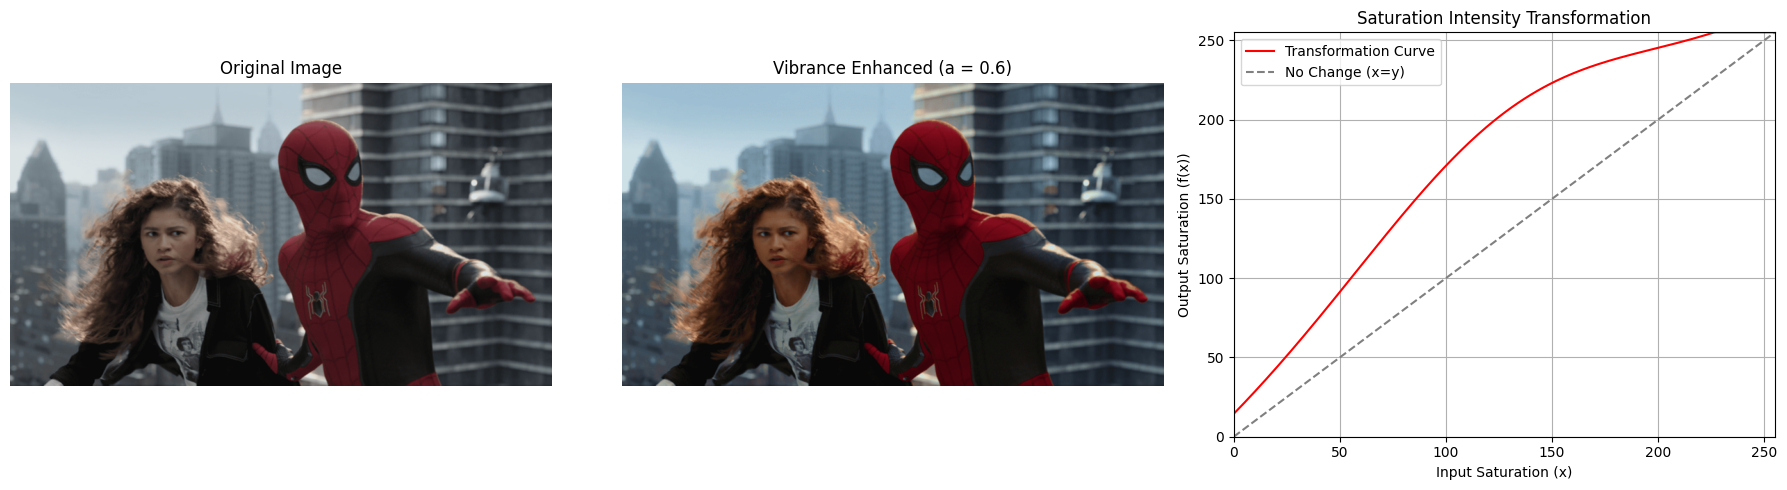

In [28]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig4.png')
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(img_hsv)

a = 0.6
sigma = 70

s_float = s.astype(np.float32)

boost = a * 128.0 * np.exp(-((s_float - 128.0)**2) / (2 * sigma**2))
s_enhanced = s_float + boost

s_enhanced = np.clip(s_enhanced, 0, 255).astype(np.uint8)

img_hsv_enhanced = cv2.merge((h, s_enhanced, v))

img_rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb_enhanced = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_rgb_enhanced)
plt.title(f'Vibrance Enhanced (a = {a})')
plt.axis('off')

x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = x_vals + a * 128.0 * np.exp(-((x_vals - 128.0)**2) / (2 * sigma**2))
y_vals = np.clip(y_vals, 0, 255)

plt.subplot(1, 3, 3)
plt.plot(x_vals, y_vals, color='red', label='Transformation Curve')
plt.plot([0, 255], [0, 255], color='gray', linestyle='--', label='No Change (x=y)')
plt.title('Saturation Intensity Transformation')
plt.xlabel('Input Saturation (x)')
plt.ylabel('Output Saturation (f(x))')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()